# Day 4 · Explainability, calibration and stability

In [1]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
PREVIOUS_SUPPORT = {
    "scripts/day2_validation.py": ("1e1da4acbee8941bef07245b259fb6c27ced4ad7", "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"),
    "scripts/day3_decision.py": ("c2dc52e129878d0d487db1874891c658de7c4d0d", "40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12")}
for relative, (revision, digest) in PREVIOUS_SUPPORT.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{revision}/{relative}", ROOT / relative, digest)
LAB_REVISION = "4f6892d5c02923b5f8e3c78f4fcead73b043570f"
SUPPORT_HASHES = {'scripts/day4_trust.py': '7e0f54bdbed94b28d09cddd02ce0ba0471d5046f05c7b70589e3e4be9902f20c', 'data/day4_shap_example.npz': 'de6eefb4f0b1dfd54d4a71e2b73cf8383cea6386e661f8af8662d478cd957e2b', 'data/day4_shap_example.json': '8169c70dc327a7ffdff748c365d71544fe951f3b196974e33f09dccb580a8122'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}", ROOT / relative, digest)
print("Day 4 setup verified | إعداد اليوم الرابع جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 4 setup verified | إعداد اليوم الرابع جاهز


In [2]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from scipy.special import expit
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications
from day4_trust import (TARGET, ROLES, TrustConfig, split_roles, fit_and_calibrate,
    probability_metrics, reliability_table, permutation_report, explain_sample, load_shap_example,
    ShapBudgetExpired, reason_codes, local_stability, cluster_bootstrap, choose_policy_threshold,
    transport_threshold, map_probability, review_audit, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = TrustConfig() if FAST_MODE else TrustConfig(trees=160, shap_rows=600, permutation_repeats=5, bootstrap_repeats=500)
USE_SHAP_EXAMPLE = False  # Discussion only; not a personal submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
parts, assignments = split_roles(train)
role_summary = pd.DataFrame([{"role": r, "rows": len(p), "customers": p.customer_id.nunique(),
    "positives": int(p[TARGET].sum()), "positive_rate": p[TARGET].mean(),
    "first_date": p.application_date.min(), "last_date": p.application_date.max()} for r, p in parts.items()])
display(role_summary)
print("Excluded gaps/customer overlaps:", int((assignments.role == "excluded_gap_or_customer").sum()))
model, calibrated_model, predictions, provenance = fit_and_calibrate(parts, contract, config)
evaluation = predictions[predictions.role == "evaluation"].copy()
policy_rows = predictions[predictions.role == "policy"].copy()
chosen_policy, policy_sweep = choose_policy_threshold(policy_rows)
mapping = provenance["calibration_mapping"]
calibrated_threshold = transport_threshold(chosen_policy["threshold"], mapping)
print("Model, sigmoid and policy threshold frozen before evaluation.")

,role,rows,customers,positives,positive_rate,first_date,last_date
0,fit,2516,1853,217,0.086248,2022-01-01,2023-04-01
1,calibration,584,538,40,0.068493,2023-07-01,2023-09-30
2,policy,589,566,55,0.093379,2024-01-01,2024-03-31
3,evaluation,1733,1520,139,0.080208,2024-07-01,2024-12-31


Excluded gaps/customer overlaps: 4578
Model, sigmoid and policy threshold frozen before evaluation.


,feature_group,mean_ap_drop,repeat_sd,training_gain
0,bureau_score,0.1270,0.0235,8922.6701
1,dti,0.0690,0.0200,6423.5164
2,loan_amount_sar,0.0140,0.0095,2372.2859
3,savings_balance_sar,0.0094,0.0032,2129.8893
4,prior_defaults,0.0065,0.0021,1109.2766
5,recent_inquiries,0.0064,0.0089,902.9509
6,income_sar,0.0062,0.0058,2214.5619
7,utilization_ratio,0.0057,0.0011,2035.9451
8,region_indicators_joint,0.0047,0.0020,360.9725
9,months_employed,0.0025,0.0044,2482.2264


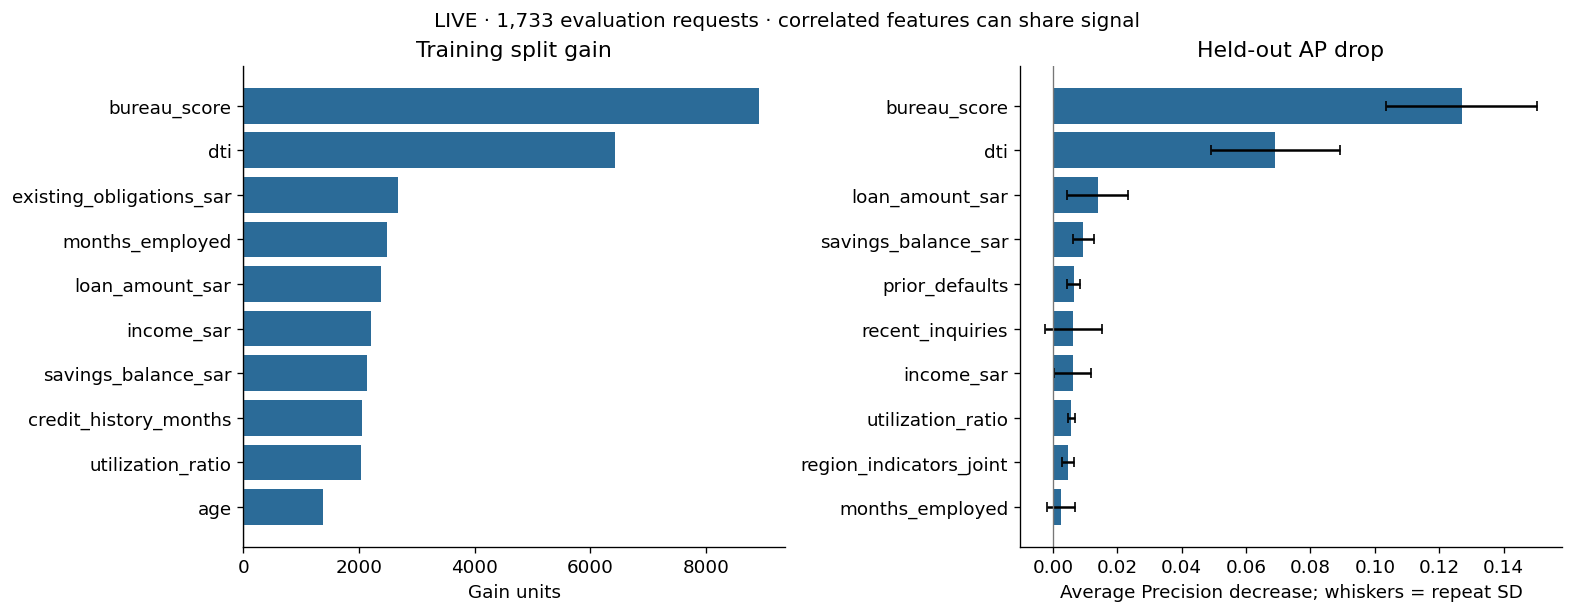

In [3]:
permutation = permutation_report(model, parts["evaluation"], contract, config)
display(permutation[["feature_group", "mean_ap_drop", "repeat_sd", "training_gain"]].head(10).round(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for ax, value, title in [(axes[0], "training_gain", "Training split gain"), (axes[1], "mean_ap_drop", "Held-out AP drop")]:
    top = permutation.nlargest(10, value).sort_values(value)
    ax.barh(top.feature_group, top[value], color="#2b6b98",
            xerr=top.repeat_sd if value == "mean_ap_drop" else None, capsize=3)
    ax.axvline(0, color="#777", lw=.8); ax.set_title(title)
    ax.set_xlabel("Gain units" if value == "training_gain" else "Average Precision decrease; whiskers = repeat SD")
fig.suptitle(f"LIVE · {len(evaluation):,} evaluation requests · correlated features can share signal", fontsize=12)
fig.savefig(ARTIFACTS / "permutation_importance.png", bbox_inches="tight"); plt.show()

,feature,mean_absolute_shap_log_odds
4,bureau_score,0.9042
5,dti,0.5437
2,loan_amount_sar,0.3490
10,savings_balance_sar,0.2169
9,existing_obligations_sar,0.2022
8,prior_defaults,0.1830
6,months_employed,0.1584
1,income_sar,0.1549
7,recent_inquiries,0.1492
13,utilization_ratio,0.1287


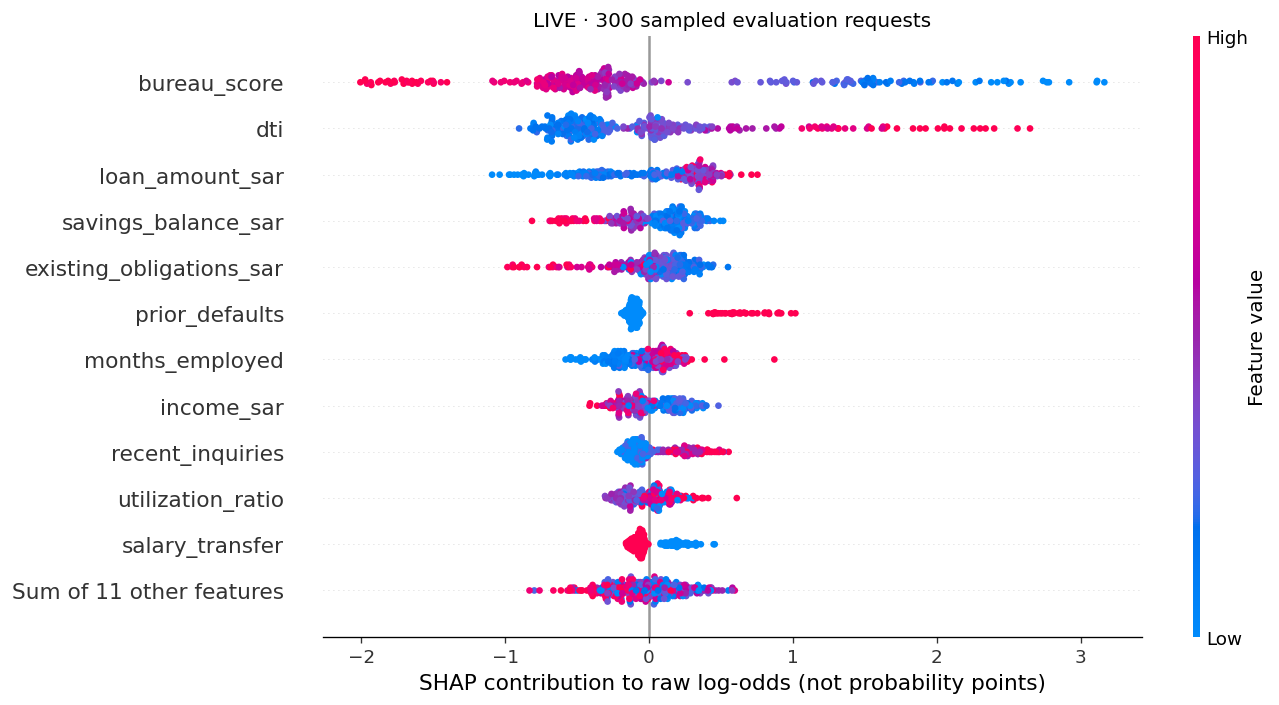

Maximum additivity error: 5.6968318951078345e-15


In [4]:
try:
    if USE_SHAP_EXAMPLE:
        raise ShapBudgetExpired("Educational example requested.")
    shap_arrays, shap_metadata = explain_sample(model, parts["evaluation"], contract, config)
except ShapBudgetExpired:
    shap_arrays, shap_metadata = load_shap_example(ROOT / "data/day4_shap_example.npz",
        ROOT / "data/day4_shap_example.json", model, parts["evaluation"], contract, ASSESSMENT_MODE)

import shap
EXPLANATION_SOURCE = shap_metadata["source"]
if EXPLANATION_SOURCE != "LIVE":
    print("EDUCATIONAL_EXAMPLE — مثال موسوم للمناقشة، غير صالح للتسليم كتجربتك. أعد SHAP لاحقًا.")
explanation = shap.Explanation(values=shap_arrays["values"], base_values=shap_arrays["base_values"],
    data=shap_arrays["data"], feature_names=list(shap_arrays["feature_names"]))
shap_global = pd.DataFrame({"feature": shap_arrays["feature_names"],
    "mean_absolute_shap_log_odds": np.abs(shap_arrays["values"]).mean(axis=0)}).sort_values("mean_absolute_shap_log_odds", ascending=False)
display(shap_global.head(10).round(4))
plt.figure()
shap.plots.beeswarm(explanation, max_display=12, show=False, plot_size=(11, 6.5))
plt.xlabel("SHAP contribution to raw log-odds (not probability points)")
plt.title(f"{EXPLANATION_SOURCE} · {len(shap_arrays['application_ids'])} sampled evaluation requests", fontsize=12)
plt.savefig(ARTIFACTS / "shap_beeswarm.png", bbox_inches="tight"); plt.show()
print("Maximum additivity error:", shap_metadata["max_additivity_error"])

TR-009585 | raw score=0.9031 | calibrated probability=0.4795


,feature,value_used,was_imputed,contribution_log_odds,reason_ar
0,bureau_score,497.0000,False,2.269325,استخدم النموذج درجة ائتمانية اصطناعية عند الطل...
1,dti,1.2806,False,1.198145,استخدم النموذج نسبة الالتزام مع القسط المقترح ...
2,loan_amount_sar,93437.2900,False,0.200725,استخدم النموذج مبلغ التمويل المطلوب بالقيمة 93...


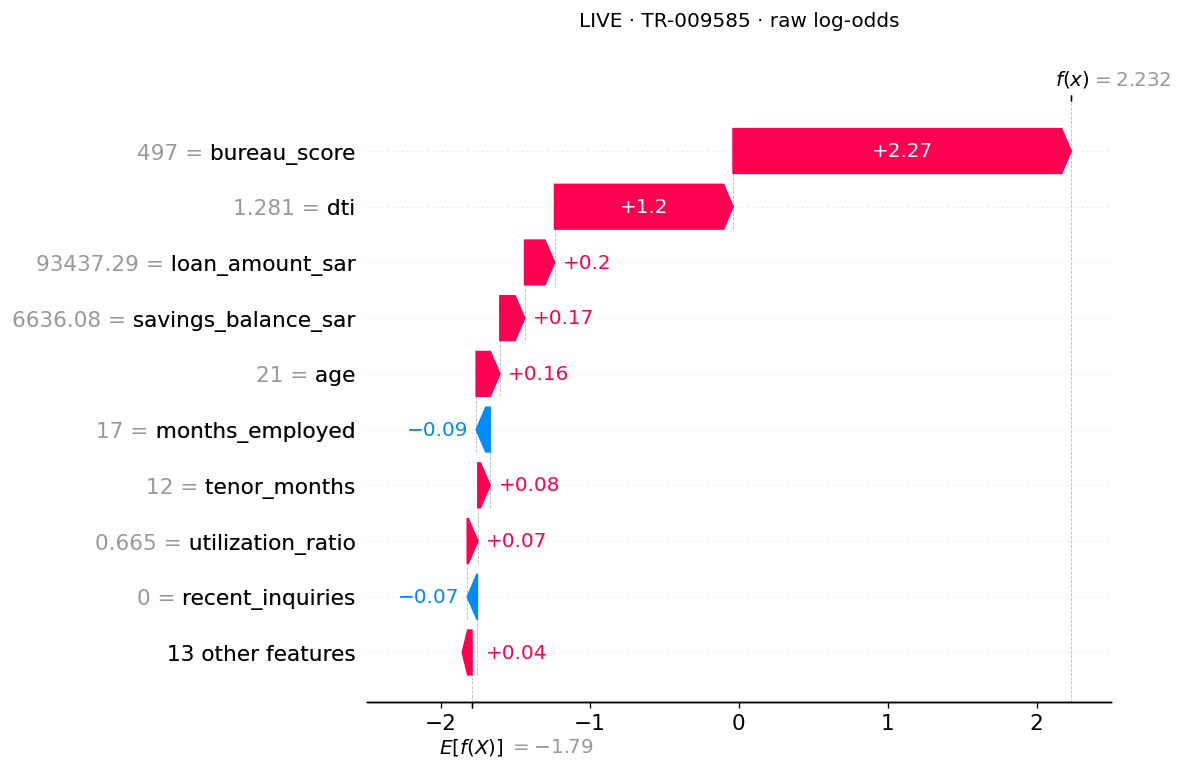

,perturbation,bureau_score_used,raw_probability,calibrated_probability,top_positive_features,shared_top_reasons,reference_reasons,source
0,bureau_score +0,497.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE
1,bureau_score -1,496.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE
2,bureau_score +1,498.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE


In [5]:
local_index = int(np.argmax(shap_arrays["raw_margin"]))
local_id = str(shap_arrays["application_ids"][local_index])
case = parts["evaluation"].set_index("application_id", drop=False).loc[[local_id]]
descriptions = {f["name"]: f["description_ar"] for f in contract["features"]}
reasons = reason_codes(shap_arrays["values"][local_index], shap_arrays["feature_names"],
    shap_arrays["data"][local_index], descriptions)
reasons["application_id"] = local_id
reasons["was_imputed"] = [bool(case.iloc[0][feature] != case.iloc[0][feature]) for feature in reasons.feature]
reasons["source"] = EXPLANATION_SOURCE
raw_local = float(expit(shap_arrays["raw_margin"][local_index]))
cal_local = float(map_probability(raw_local, mapping))
print(f"{local_id} | raw score={raw_local:.4f} | calibrated probability={cal_local:.4f}")
display(reasons[["feature", "value_used", "was_imputed", "contribution_log_odds", "reason_ar"]])
plt.figure()
shap.plots.waterfall(explanation[local_index], max_display=10, show=False)
plt.title(f"{EXPLANATION_SOURCE} · {local_id} · raw log-odds", fontsize=12, pad=45)
plt.savefig(ARTIFACTS / "shap_waterfall.png", bbox_inches="tight"); plt.show()
if EXPLANATION_SOURCE == "LIVE":
    local_checks = local_stability(model, case, contract, mapping)
    local_checks["source"] = "LIVE"
    display(local_checks)
else:
    local_checks = pd.DataFrame(columns=["perturbation", "bureau_score_used", "raw_probability", "calibrated_probability",
        "top_positive_features", "shared_top_reasons", "reference_reasons", "source"])
    print("Local perturbation check skipped in example mode; do not claim it ran.")

,rows,positives,roc_auc,average_precision,brier,ece,log_loss
raw,1733,139,0.770804,0.258677,0.113027,0.146871,0.357993
sigmoid,1733,139,0.770804,0.258677,0.067112,0.022486,0.246749


Measured change (after - before): Brier -0.04592, ECE -0.12438


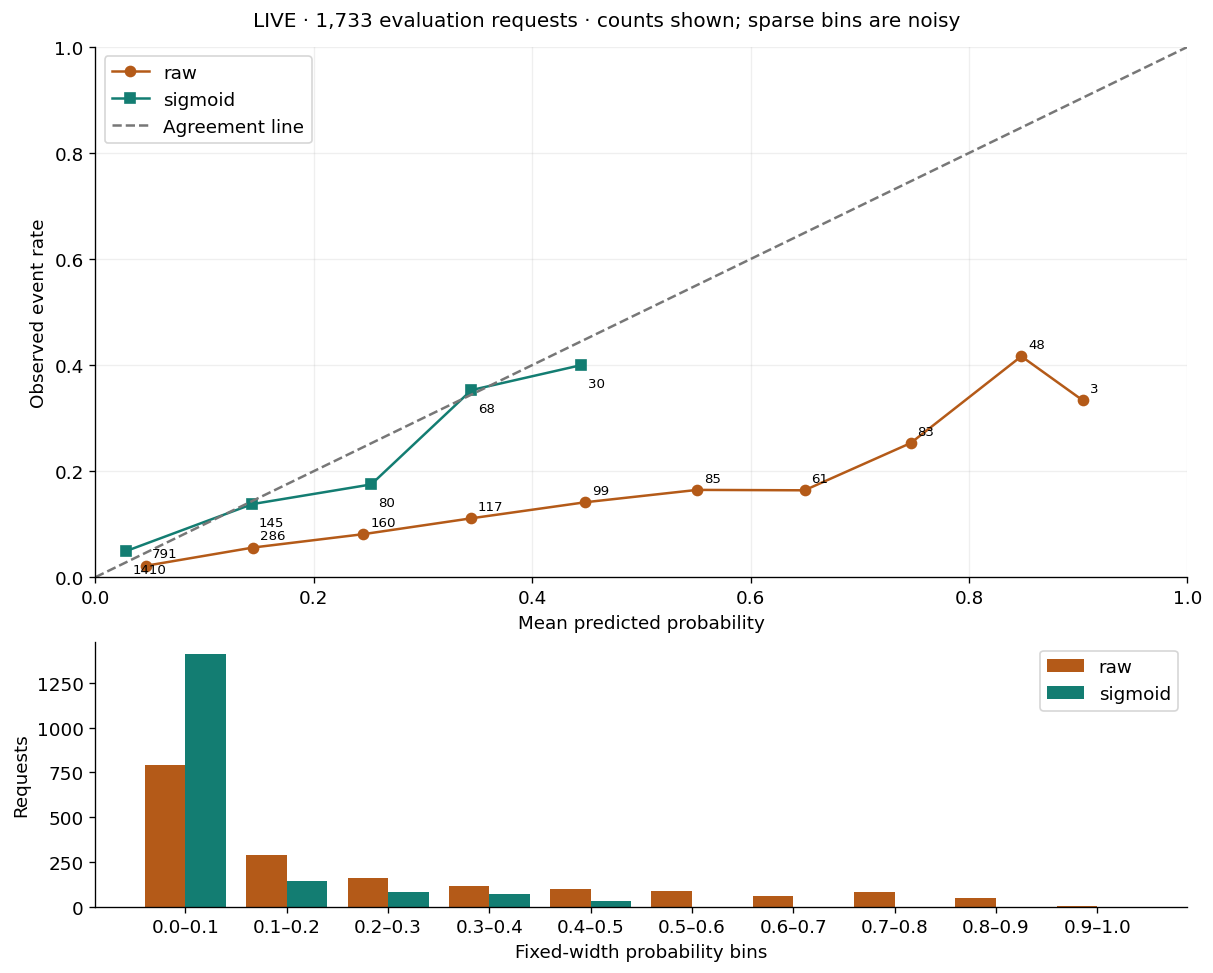

In [6]:
calibration_metrics, bin_tables = {}, []
for label, column in [("raw", "raw_probability"), ("sigmoid", "calibrated_probability")]:
    calibration_metrics[label] = probability_metrics(evaluation[TARGET], evaluation[column])
    table = reliability_table(evaluation[TARGET], evaluation[column]); table["variant"] = label
    bin_tables.append(table)
reliability = pd.concat(bin_tables, ignore_index=True)
display(pd.DataFrame(calibration_metrics).T[["rows", "positives", "roc_auc", "average_precision", "brier", "ece", "log_loss"]].round(5))
brier_delta = calibration_metrics["sigmoid"]["brier"] - calibration_metrics["raw"]["brier"]
ece_delta = calibration_metrics["sigmoid"]["ece"] - calibration_metrics["raw"]["ece"]
print(f"Measured change (after - before): Brier {brier_delta:+.5f}, ECE {ece_delta:+.5f}")
fig, axes = plt.subplots(2, 1, figsize=(10, 8), layout="constrained", gridspec_kw={"height_ratios": [2, 1]})
for label, color, marker in [("raw", "#b45a18", "o"), ("sigmoid", "#137d72", "s")]:
    bins = reliability[reliability.variant == label]; nonempty = bins[bins['count'] > 0]
    axes[0].plot(nonempty.mean_probability, nonempty.observed_rate, marker=marker, color=color, label=label)
    for row in nonempty.itertuples():
        axes[0].annotate(str(row.count), (row.mean_probability, row.observed_rate), xytext=(4, 5 if label == "raw" else -13), textcoords="offset points", fontsize=8)
    positions = bins['bin'] + (-.2 if label == "raw" else .2)
    axes[1].bar(positions, bins['count'], width=.4, color=color, label=label)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#777", label="Agreement line")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted probability", ylabel="Observed event rate")
axes[0].legend(); axes[0].grid(alpha=.2)
axes[1].set(xticks=np.arange(10), xticklabels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], ylabel="Requests", xlabel="Fixed-width probability bins")
axes[1].legend()
fig.suptitle(f"LIVE · {len(evaluation):,} evaluation requests · counts shown; sparse bins are noisy", fontsize=12)
fig.savefig(ARTIFACTS / "reliability_curve.png", bbox_inches="tight"); plt.show()

,period,variant,rows,positives,average_precision,brier,ece
0,2024Q3,raw,836,78,0.27457,0.11528,0.13397
1,2024Q3,sigmoid,836,78,0.27457,0.07760,0.03229
2,2024Q4,raw,897,61,0.27050,0.11093,0.15890
3,2024Q4,sigmoid,897,61,0.27050,0.05734,0.02434


Paired customer-cluster 95% percentile intervals:


,lower,upper
raw_ap,0.197442,0.337854
calibrated_ap,0.197442,0.337854
brier_change,-0.054177,-0.037409


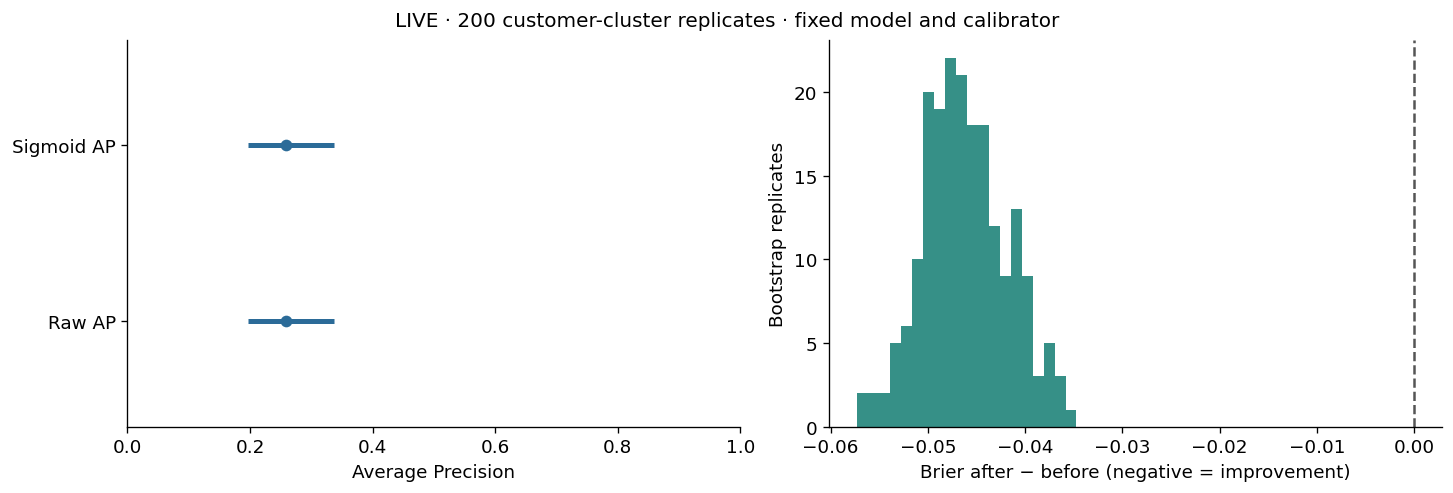

In [7]:
bootstrap, stability_summary = cluster_bootstrap(evaluation, config)
period_rows = []
for period, group in evaluation.groupby(pd.to_datetime(evaluation.application_date).dt.to_period("Q").astype(str)):
    for variant, column in [("raw", "raw_probability"), ("sigmoid", "calibrated_probability")]:
        period_rows.append({"period": period, "variant": variant, **probability_metrics(group[TARGET], group[column])})
period_metrics = pd.DataFrame(period_rows)
display(period_metrics[["period", "variant", "rows", "positives", "average_precision", "brier", "ece"]].round(5))
stability_summary["period_ap_sample_sd"] = {v: float(g.average_precision.std(ddof=1)) for v, g in period_metrics.groupby("variant")}
print("Paired customer-cluster 95% percentile intervals:")
display(pd.DataFrame({key: stability_summary[key] for key in ("raw_ap", "calibrated_ap", "brier_change")}).T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for i, key in enumerate(("raw_ap", "calibrated_ap")):
    interval = stability_summary[key]
    point = calibration_metrics["raw" if i == 0 else "sigmoid"]["average_precision"]
    if interval is not None:
        axes[0].hlines(i, interval["lower"], interval["upper"], color="#2b6b98", lw=3)
    axes[0].plot(point, i, "o", color="#2b6b98")
axes[0].set(yticks=[0, 1], yticklabels=["Raw AP", "Sigmoid AP"], xlabel="Average Precision", xlim=(0, 1), ylim=(-.6, 1.6))
axes[1].hist(bootstrap.brier_change, bins=20, color="#137d72", alpha=.85)
axes[1].axvline(0, color="#555", linestyle="--"); axes[1].set(xlabel="Brier after − before (negative = improvement)", ylabel="Bootstrap replicates")
fig.suptitle(f"LIVE · {stability_summary['valid']} customer-cluster replicates · fixed model and calibrator", fontsize=12)
fig.savefig(ARTIFACTS / "stability_summary.png", bbox_inches="tight"); plt.show()

,threshold,flagged,fn,fp,loss_units,capacity,feasible,calibrated_threshold,selection_role
0,0.588195,68,34,47,387.0,70,True,0.17331,policy


,period,rows,capacity,risk_flags,near_threshold,candidate_review,risk_within_capacity,candidate_within_capacity,loss_units
0,2024Q3,836,100,97,23,109,True,False,536.0
1,2024Q4,897,107,109,21,122,False,False,444.0


CAPACITY_REVIEW_REQUIRED | Do not retune on evaluation.


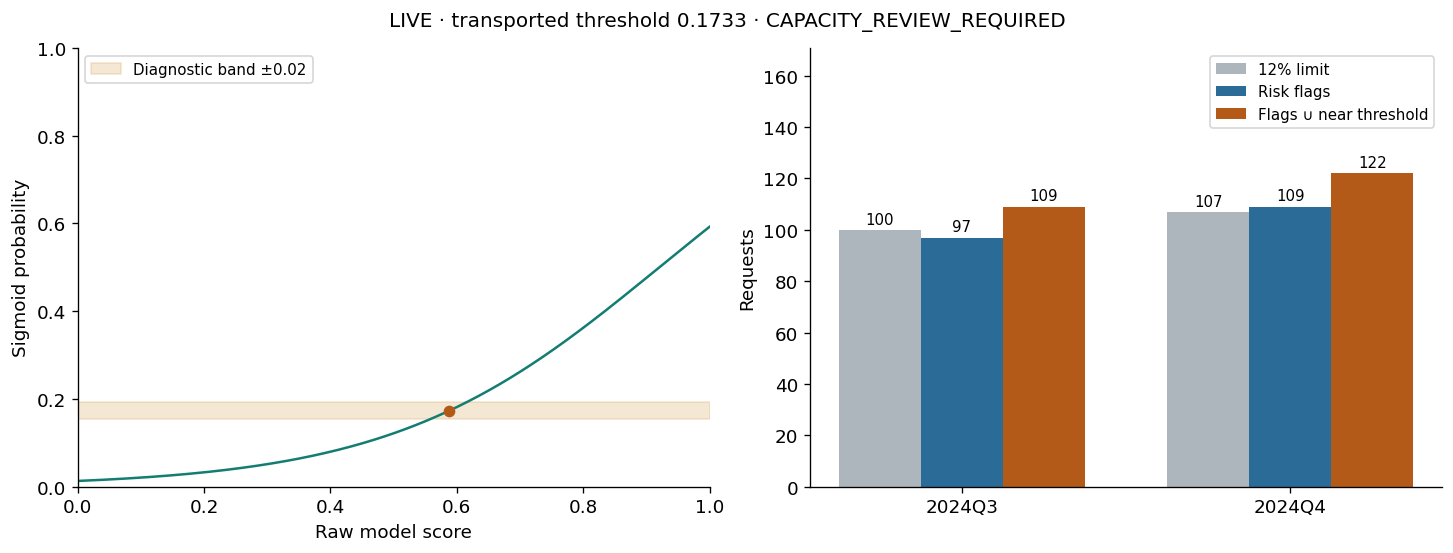

In [8]:
review_flags, capacity_audit, review_band = review_audit(evaluation, chosen_policy["threshold"],
    calibrated_threshold, config.review_half_width)
policy_status = "CAPACITY_REVIEW_REQUIRED" if not capacity_audit.candidate_within_capacity.all() else "WITHIN_OBSERVED_CAPACITY"
display(pd.DataFrame([{**chosen_policy, "calibrated_threshold": calibrated_threshold, "selection_role": "policy"}]))
display(capacity_audit)
print(policy_status, "| Do not retune on evaluation.")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
grid = np.linspace(0, 1, 300)
axes[0].plot(grid, map_probability(grid, mapping), color="#137d72")
axes[0].axhspan(review_band['lower'], review_band['upper'], color="#d7a354", alpha=.25, label="Diagnostic band ±0.02")
axes[0].plot(chosen_policy['threshold'], calibrated_threshold, 'o', color="#b45a18")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Raw model score", ylabel="Sigmoid probability")
axes[0].legend(loc="upper left", fontsize=9)
x = np.arange(len(capacity_audit))
for offset, column, label, color in [(-.25, 'capacity', '12% limit', '#aeb6bd'), (0, 'risk_flags', 'Risk flags', '#2b6b98'), (.25, 'candidate_review', 'Flags ∪ near threshold', '#b45a18')]:
    bars = axes[1].bar(x+offset, capacity_audit[column], width=.25, label=label, color=color)
    axes[1].bar_label(bars, padding=2, fontsize=9)
axes[1].set(xticks=x, xticklabels=capacity_audit.period, ylabel="Requests", ylim=(0, capacity_audit.candidate_review.max()*1.4))
axes[1].legend(fontsize=9)
fig.suptitle(f"LIVE · transported threshold {calibrated_threshold:.4f} · {policy_status}", fontsize=12)
fig.savefig(ARTIFACTS / "review_zone.png", bbox_inches="tight"); plt.show()

In [10]:
responses = {
    "global_local": "Globally, permutation importance on 1,733 evaluation requests shows bureau_score (AP drop 0.127) and dti (0.069) dominate, and mean |SHAP| agrees (0.90 and 0.54 log-odds). Locally, request TR-009585 is driven by a low bureau_score of 497 (+2.27) and a high dti of 1.28 (+1.20). Global importance describes the whole sample; a local explanation describes one request and can differ from the global ranking.",
    "output_units": "SHAP values are in raw log-odds, not probability points: they add up from the base value E[f(X)] = -1.79 to f(x) = 2.23 for this request (additivity error 5.7e-15). A +2.27 contribution is not +227% or +2.27 percentage points. Probabilities are shown separately: raw score 0.903, calibrated 0.48.",
    "reason_limits": "SHAP explains the fitted model, not real-world causes, and correlated features (income, obligations, savings) can share or swap credit. Gain in training and held-out permutation rank features differently (months_employed is high in gain but near zero in permutation). Reason codes are not proof of fairness or legal compliance, and the data are synthetic.",
    "calibration_evidence": "Sigmoid calibration was learned only on the Jul-Sep 2023 calibration rows and measured on evaluation. Brier fell from 0.113 to 0.067 and ECE from 0.147 to 0.022, while ROC-AUC (0.771) and AP (0.259) did not change, because calibration changes probability values, not ranking. Bins above 0.4 hold few requests, so they are noisy.",
    "stability": "With 200 customer-cluster bootstrap replicates, the 95% interval for AP is 0.197 to 0.338, so a single AP value is uncertain. The Brier change stays negative in the whole interval (-0.054 to -0.037), and both evaluation quarters improved (ECE 0.134 to 0.032 and 0.159 to 0.024). The local top three reasons stayed the same when bureau_score moved by +/-1.",
    "review_capacity": "The policy threshold (raw 0.588, calibrated 0.173) was feasible on policy rows (68 flags vs capacity 70). On evaluation it flags 97 of 100 allowed in 2024Q3 but 109 of 107 in 2024Q4, and the +/-0.02 review band raises this to 109 and 122. Status is CAPACITY_REVIEW_REQUIRED: the threshold must not be retuned on evaluation data; the overrun must be escalated and monitored."
}
checkpoint = reflection_check(responses, EXPLANATION_SOURCE)
print(checkpoint["status"], "| Fields to complete:", checkpoint["missing"])

READY_FOR_REVIEW | Fields to complete: []


In [11]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, np.ndarray)): return [json_safe(v) for v in value]
    if isinstance(value, (np.integer,)): return int(value)
    if isinstance(value, (np.bool_,)): return bool(value)
    if isinstance(value, (float, np.floating)): return float(value) if np.isfinite(value) else None
    return value

technical_status = "TECHNICAL_READY" if EXPLANATION_SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
calibration_payload = {"source": "LIVE", "evaluation_role": "evaluation", "metrics": calibration_metrics,
    "mapping": mapping, "policy_selection": chosen_policy, "calibrated_threshold": calibrated_threshold,
    "review_band": review_band, "capacity_status": policy_status, "brier_change": brier_delta, "ece_change": ece_delta,
    "prior_course_exposure": True, "not_a_final_untouched_test": True}
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "explanation_source": EXPLANATION_SOURCE, "model_calibration_source": "LIVE", "config": asdict(config),
    "assessment_mode": ASSESSMENT_MODE, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "previous_support": PREVIOUS_SUPPORT, "data_revision": COURSE_REVISION, "python": platform.python_version(),
    "elapsed_seconds": round(time.perf_counter()-RUN_STARTED, 2), "capacity_status": policy_status,
    "challenge_used_for_modeling": False, "no_automatic_grade": True}
csv_outputs = {"day4_roles.csv": assignments, "day4_predictions.csv": predictions,
    "permutation_importance.csv": permutation, "day4_shap_global.csv": shap_global.assign(source=EXPLANATION_SOURCE),
    "day4_reason_codes.csv": reasons, "day4_local_stability.csv": local_checks,
    "day4_reliability_bins.csv": reliability, "day4_period_metrics.csv": period_metrics,
    "day4_bootstrap.csv": bootstrap, "day4_policy_sweep.csv": policy_sweep,
    "day4_review_flags.csv": review_flags, "day4_capacity.csv": capacity_audit}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
np.savez_compressed(ARTIFACTS / "shap_values_sample.npz", **shap_arrays)
model.named_steps["model"].booster_.save_model(str(ARTIFACTS / "day4_model.txt"))
json_outputs = {"calibration_metrics.json": calibration_payload, "day4_shap_metadata.json": shap_metadata,
    "day4_stability_summary.json": stability_summary, "day4_provenance.json": provenance,
    "day4_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day4_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
status_text = "مثال تعليمي غير صالح للتسليم كتجربة شخصية" if EXPLANATION_SOURCE != "LIVE" else ("مسودة — أكمل تفسيرك" if checkpoint['missing'] else "جاهز للمراجعة؛ لا يعني اعتمادًا أو درجة")
reason_text = "\n".join(f"- {r.reason_ar} (SHAP={r.contribution_log_odds:+.4f} log-odds؛ قيمة معوضة: {r.was_imputed})" for r in reasons.itertuples())
capacity_text = "\n".join(f"- {r.period}: السقف {r.capacity}، الإشارات {r.risk_flags}، اتحاد المراجعة {r.candidate_review}." for r in capacity_audit.itertuples())
report = f"""# تقريرك: التفسير والمعايرة — Tamweel Lite

**الحالة:** {status_text}

**مصدر التفسير:** {EXPLANATION_SOURCE}. **النموذج والمعايرة:** LIVE. **السعة:** {policy_status}.

## النموذج والأدوار
LightGBM موزون، {config.trees} شجرة. الهدف حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. الأدوار منفصلة زمنيًا وبالعملاء: تدريب {len(parts['fit'])}، معايرة {len(parts['calibration'])} ({int(parts['calibration'][TARGET].sum())} موجب)، سياسة {len(parts['policy'])}، تقييم {len(evaluation)}. الفجوات والتداخلات مستبعدة. سبق استخدام بيانات التقييم في الدورة، فهي ليست اختبارًا نهائيًا لم يمسّ.

## التفسير العام والمحلي
Permutation يقيس انخفاضAP على التقييم؛ إشارات المنطقة تُبدّل معًا. SHAP يفسر النموذج الخام بوحدةlog-odds وخلفية مسارات أشجار التدريب. base+sum(SHAP)=raw margin، ثمsigmoid للمجموع فقط. القيم ليست نقاط احتمال ولا تفسيرًا مباشرًا للنموذج المعاير.

{answer('global_local')}

{answer('output_units')}

الطلب الاصطناعي {local_id}: الدرجة الخام {raw_local:.5f} والاحتمال المعاير {cal_local:.5f}. اختير أعلى درجة داخل عينةSHAP دون استخدام النتيجة الفعلية.
{reason_text}

{answer('reason_limits')}

## دليل المعايرة
على {len(evaluation)} صفًا و{int(evaluation[TARGET].sum())} موجب: Brier {calibration_metrics['raw']['brier']:.6f} → {calibration_metrics['sigmoid']['brier']:.6f}؛ ECE {calibration_metrics['raw']['ece']:.6f} → {calibration_metrics['sigmoid']['ece']:.6f}. عشر حاويات متساوية العرض مع أعدادها فيday4_reliability_bins.csv. AP {calibration_metrics['raw']['average_precision']:.6f} → {calibration_metrics['sigmoid']['average_precision']:.6f}؛ ROC-AUC {calibration_metrics['raw']['roc_auc']:.6f} → {calibration_metrics['sigmoid']['roc_auc']:.6f}. هذه نتائج هذه العينة وليست ضمانًا لتحسن مستقبلي.

{answer('calibration_evidence')}

## الاستقرار
{stability_summary['valid']} تكرارbootstrap صالح بسحب العملاء؛ فترات مئينية95% مع تثبيت النموذج والمعاير. لا تشمل تعلم النموذج أو المعايرة أو الانجراف المستقبلي، ولا تصف احتمال فرد. انحرافAP بين ربعي التقييم وصفي فقط. اختبارbureau_score±1 {'نُفذ؛ راجع day4_local_stability.csv' if EXPLANATION_SOURCE == 'LIVE' else 'لم ينفذ في وضع المثال'}.

{answer('stability')}

## العتبة ومنطقة المراجعة
العتبة الخام {chosen_policy['threshold']!r} اختيرت علىpolicy بخسارة10×FN+FP وسقف12% ثم نُقلت إلى {calibrated_threshold!r}. لم تعدل باستخدام التقييم. المنطقة[{review_band['lower']:.5f}, {review_band['upper']:.5f}] تشخيصية بعرض±0.02 وليست فترة ثقة. الاتحاد يحسب الطلب مرة واحدة.
{capacity_text}

{answer('review_capacity')}

عند تجاوز السعة، وثّق الحاجة إلى تصميم سياسة جديدة على بيانات تطوير وتقييمها بدليل جديد. لا ترفع السقف ولا تقص الحالات بعد رؤية النتيجة. التفسير ليس سببية أو شهادة عدالة، والخسارة وحدات تعليمية لا رسوم أو خصم درجات. لا يستخدم هذا التمرين لتمويل حقيقي.
"""
(REPORTS / "INTERPRETABILITY_REPORT.md").write_text(report, encoding="utf-8")
figures = ["permutation_importance.png", "shap_beeswarm.png", "shap_waterfall.png", "reliability_curve.png", "stability_summary.png", "review_zone.png"]
artifact_files = list(csv_outputs) + list(json_outputs) + figures + ["environment.json", "shap_values_sample.npz", "day4_model.txt"]
with zipfile.ZipFile(ARTIFACTS / "day4_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files: bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "INTERPRETABILITY_REPORT.md", "reports/INTERPRETABILITY_REPORT.md")
print(f"{technical_status} | {checkpoint['status']} | {EXPLANATION_SOURCE} | CPU")
print(f"Saved {len(artifact_files)+1} files in day4_artifacts.zip | {policy_status}")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | CPU
Saved 28 files in day4_artifacts.zip | CAPACITY_REVIEW_REQUIRED


### Day 4 summary
**Goal:** explain what the model uses and test whether its probabilities are trustworthy.

- **Roles:** fit (2,516) · calibration Jul–Sep 2023 (584) · policy Jan–Mar 2024 (589) · evaluation Jul–Dec 2024 (1,733); everything frozen before evaluation.
- **Drivers:** bureau_score (permutation AP drop 0.127, mean |SHAP| 0.90) and dti (0.069, 0.54) dominate.
- **Local example:** TR-009585, raw score 0.903 → calibrated 0.48; low bureau_score 497 (+2.27 log-odds) and high dti 1.28 (+1.20).

| Probabilities | ROC-AUC | AP | Brier | ECE |
|---|---|---|---|---|
| Raw | 0.771 | 0.259 | 0.113 | 0.147 |
| **Sigmoid** | 0.771 | 0.259 | **0.067** | **0.022** |

- **Stability:** AP 95% interval 0.197–0.338; Brier improvement stays negative (−0.054 to −0.037).
- **Capacity:** threshold 0.173 (calibrated) fits policy rows but flags 109 of 107 allowed in 2024Q4 → **CAPACITY_REVIEW_REQUIRED**; not retuned on evaluation.